In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import run_fair

import utils_MLP

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

## 1. Create CO<sub>2</sub>-only scenarios
### 1a. Training scenario setup

In [79]:
# Required parameters
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)

emis_dict = run_fair.load_cmip7_extensions(n_steps, ['CO2'])

# Idealized pulse
pulse = np.zeros(n_steps)
pulse[0] = 5000 # Pulse magnitude
emis_dict['pulse'] = run_fair.ensure_all_agents({'CO2': pulse}, n_steps)

# Idealized step (similar to 4xCO2)
step = np.zeros(n_steps)
year_step = 50
step[year_step:] = 10 # Step magnitude
emis_dict['step'] = run_fair.ensure_all_agents({'CO2': step}, n_steps)

# Sinusoid
t = np.arange(n_steps)
amplitude = 39.741618
frequency = 0.002614
sine = amplitude * np.sin(2 * np.pi * frequency * t)
emis_dict['sine'] = run_fair.ensure_all_agents({'CO2': sine}, n_steps)

# Noise
sigma = 100 # Noise standard deviation
noise = sigma * np.random.randn(n_steps)
emis_dict['noise'] = run_fair.ensure_all_agents({'CO2': noise}, n_steps)

In [3]:
def sinusoidal_cycle(t, amplitude, frequency):
  """A long-period sinusoidal cycle."""
  return amplitude * np.sin(2 * np.pi * frequency * t)

sigma, f_low, f_high = 61.540688, 0.040363, 0.115967
m_t = sinusoidal_cycle(np.arange(n_steps), 39.741618, 0.002614)

FS = 1

white_noise = np.random.randn(n_steps)
nyquist = 0.5 * FS
b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
w_t = signal.filtfilt(b, a, white_noise)
w_t -= np.mean(w_t)
w_t /= np.std(w_t)
noise_component = sigma * w_t

u_t = m_t + noise_component
emis_dict_train['Optimal'] = run_fair.ensure_all_agents({'CO2': u_t}, n_steps)

### 1b. Shock testing setup

In [4]:
# Rapid changes start in 2100 and take 25 years
shock_year = 350
shock_duration = 25

# Plateau with rapid increase, built from CMIP7-ME, HE
plat_inc = emis_dict_train['ME']['CO2'].copy()
plat_val = plat_inc[shock_year]
inc_val = emis_dict_train['HE']['CO2'][400].copy()
plat_inc[shock_year:shock_year + shock_duration] = np.linspace(plat_val, inc_val, shock_duration)
plat_inc[shock_year + shock_duration:] = emis_dict_train['HE']['CO2'][400 - shock_duration:]
emis_dict_train['plat_inc'] = run_fair.ensure_all_agents({'CO2': plat_inc}, n_steps)

# Rapid increase followed by rapid decrease, built from CMIP7-HE
inc_dec = emis_dict_train['HE']['CO2'].copy()
inc_dec[shock_year:shock_year + shock_duration] = np.linspace(inc_dec[shock_year], 0, shock_duration)
inc_dec[shock_year + shock_duration:] = 0
emis_dict_train['inc_dec'] = run_fair.ensure_all_agents({'CO2': inc_dec}, n_steps)

scenarios_all = list(emis_dict_train.keys())

In [80]:
scenarios_all = list(emis_dict.keys())

### 1c. Force FaIR with scenarios to get $\overline{\Delta T}(t)$

In [81]:
nan_force = np.zeros(n_steps)

delT_train_dict_priority_1 = {}
delT_test_dict_priority_2 = {}

agents = ['CO2','CH4','N2O','Sulfur','BC']
agents_lim = ['CO2']
CMIP7_priority_1 = ['HO','HE','VL','VLO','L','ME','MO']
CMIP7_priority_1_ext = ['HE','VL']
CMIP7_priority_2_ext = ['HO','VLO','L','ME','MO']
idealized_train = ['pulse','step','sine','noise']

for scen in scenarios_all:
  f = run_fair.build_fair(start, stop, input_mode="emissions")
  emis = {a: nan_force for a in agents}

  for agent in agents_lim:
    emis[agent] = emis_dict[scen][agent]

  run_fair.reset_state(f)
  run_fair.set_emissions(f, years, emis)
  _, T, T_mean, _ = run_fair.run_fair(f, years)

  if (scen in CMIP7_priority_1 and scen in CMIP7_priority_1_ext) or (scen in idealized_train):
    delT_train_dict_priority_1[scen] = T_mean
  elif scen in CMIP7_priority_1:
    delT_train_dict_priority_1[scen] = T_mean[:400]

  if scen in CMIP7_priority_2_ext:
    delT_test_dict_priority_2[scen] = T_mean

In [108]:
emis_dict_train.keys()

dict_keys(['HO', 'HE', 'VL', 'VLO', 'L', 'ME', 'MO', 'pulse', 'step', 'sine', 'noise'])

In [110]:
arr1 = emis_dict_train['HE']['CO2']
arr2 = emis_dict_train['VL']['CO2']
mismatch_indices = np.where(arr1[:] != arr2[:])[0]

In [111]:
mismatch_indices

array([273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285,
       286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298,
       299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311,
       312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324,
       325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337,
       338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350,
       351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363,
       364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376,
       377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389,
       390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402,
       403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415,
       416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428,
       429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441,
       442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 45

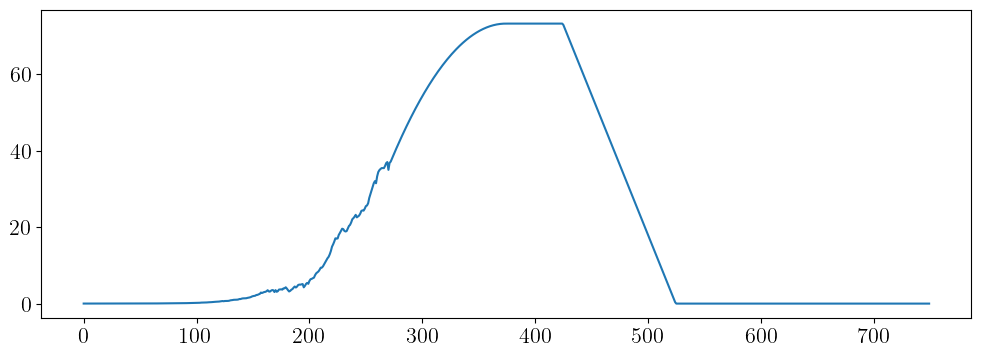

In [105]:
plt.plot(emis_dict_train['HE']['CO2'])
plt.plot(emis_dict_train['HE']['CO2'])

In [88]:
scenarios_train = [scen for scen in delT_train_dict_priority_1.keys()]
scenarios_test = [scen for scen in delT_test_dict_priority_2.keys()]

emis_dict_train, emis_dict_test = {}, {}
for scen in scenarios_train:
  emis_dict_train[scen] = {}
  for agent in agents_lim:
    if (scen in CMIP7_priority_1 and scen in CMIP7_priority_1_ext) or (scen in idealized_train):
      emis_dict_train[scen][agent] = emis_dict[scen][agent].copy()
    elif scen in CMIP7_priority_1:
      emis_dict_train[scen][agent] = emis_dict[scen][agent][:400].copy()

for scen in scenarios_test:
  emis_dict_test[scen] = {}
  for agent in agents_lim:
    if scen in CMIP7_priority_2_ext:
      emis_dict_test[scen][agent] = emis_dict[scen][agent].copy()

#### Optional: plot training scenarios

Text(0.5, 0, 'Year')

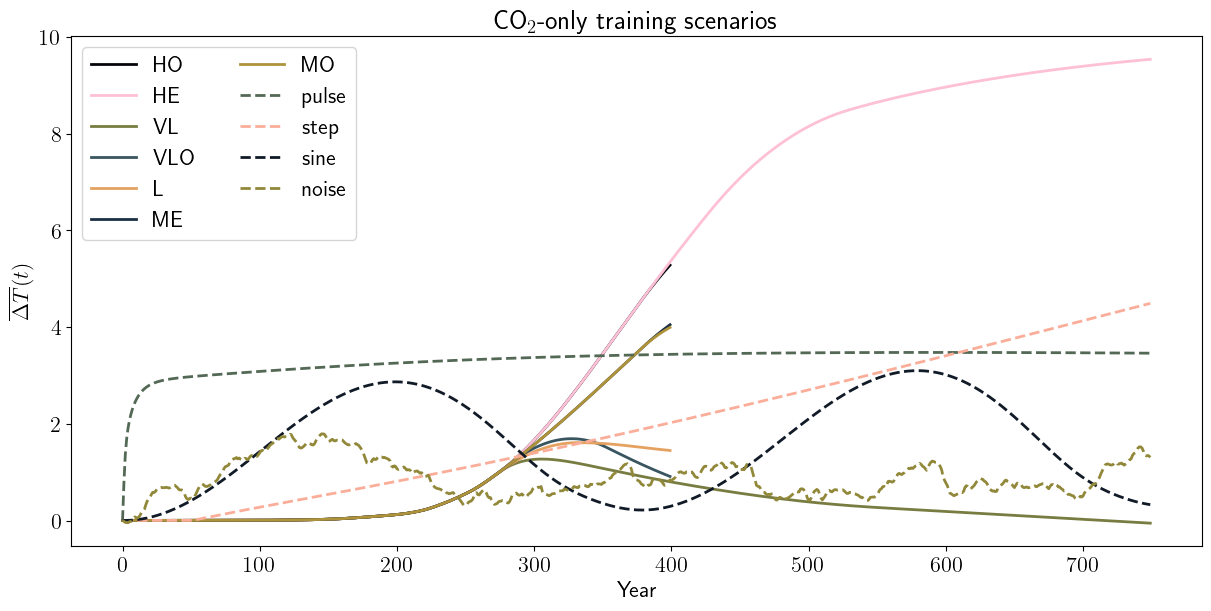

In [90]:
fig, ax = plt.subplots(figsize=(12,6), constrained_layout=True)
for i, scen in enumerate(delT_train_dict_priority_1.keys()):
  if scen in ['pulse','step','sine','noise']:
    ls = '--'
  else:
    ls = '-'
  ax.plot(delT_train_dict_priority_1[scen], label=scen, ls=ls, lw=2, c=cm.batlowKS(i))
  #ax.plot(emis_dict_train[scen]['CO2'], label=scen, ls=ls, lw=2, c=cm.batlowKS(i))
ax.legend(loc='upper left', ncol=2)
ax.set_title(r'CO$_2$-only training scenarios')
ax.set_ylabel(r'$\overline{\Delta T}(t)$')
ax.set_xlabel('Year')

## 2. Evaluate emulator performance
### 2a. Train MLPs with each individual experiment

In [91]:
series_train, series_test = [], []
for scen in scenarios_train:
  series_train.append((emis_dict_train[scen], delT_train_dict_priority_1[scen]))
for scen in scenarios_test:
  series_test.append((emis_dict_test[scen], delT_test_dict_priority_2[scen]))

agents = ['CO2']
error_dict_single, yhat_dict_single = utils_MLP.evaluate_trainsets_vs_tests(scenarios_train, series_train, scenarios_test, series_test, agents, n_lags=10, random_state=0)

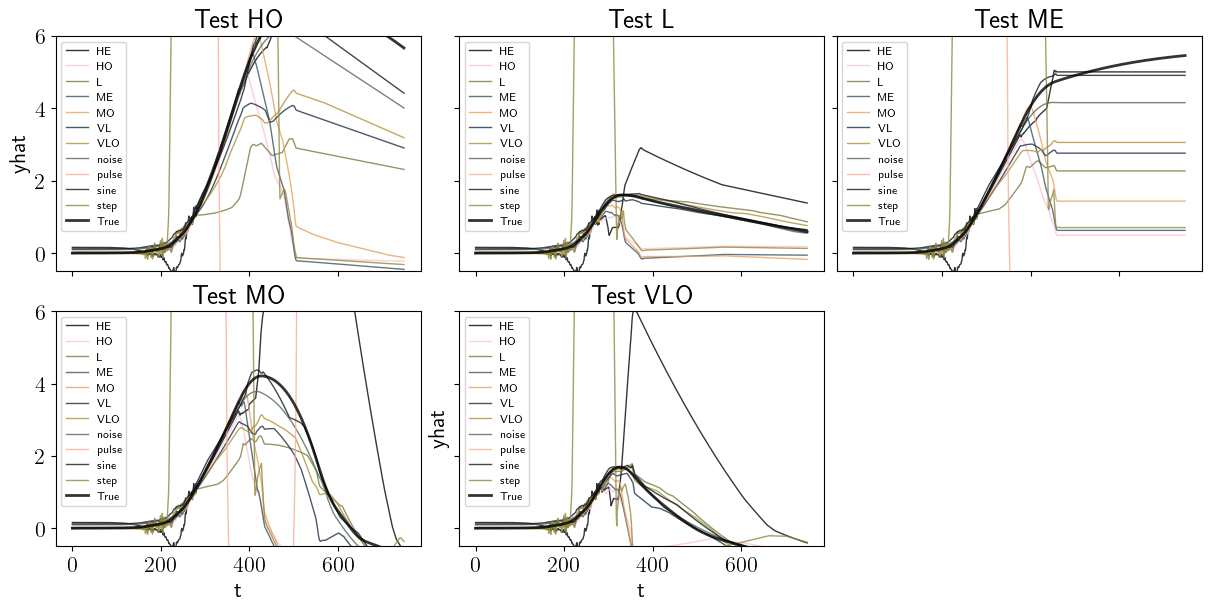

In [92]:
utils_MLP.plot_yhats_grid(error_dict_single, yhat_dict_single, delT_test_dict_priority_2)

['HO', 'VLO', 'L', 'ME', 'MO']


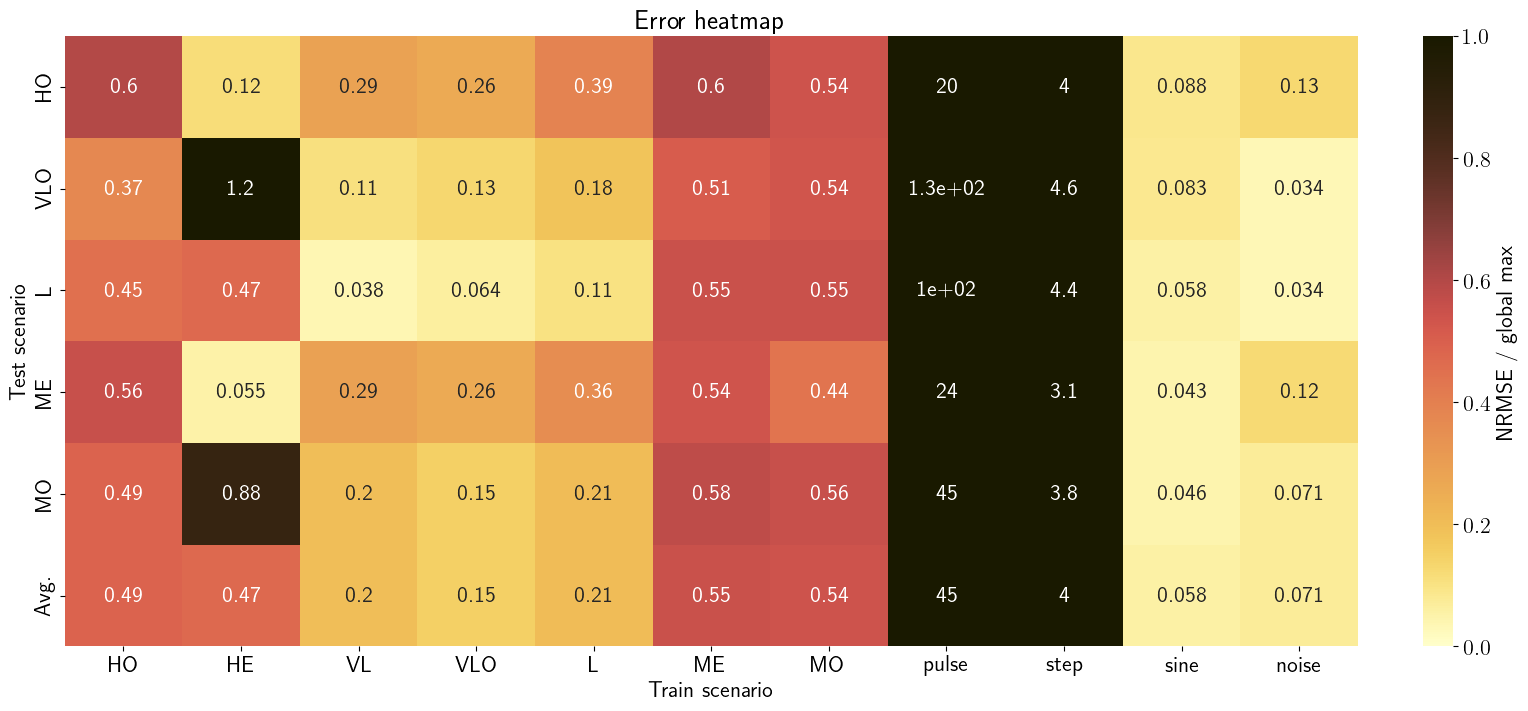

In [93]:
utils_MLP.plot_error_heatmap(error_dict_single, scenarios_train, scenarios_test)

### 2b. Train MLPs w/ multiple scenarios

In [98]:
training_groups = {'Bracket':['HE','VL']}
training_groups['All_CMIP7'] = CMIP7_priority_1.copy()

for scen in CMIP7_priority_1:
  key = f'Hold_{scen}'
  value = [tag for tag in CMIP7_priority_1 if tag != scen]
  training_groups[key] = value

training_groups['noise'] = ['noise']
training_groups['sine'] = ['sine']

error_dict_multi, yhat_dict_multi = utils_MLP.evaluate_trainsets_vs_tests(scenarios_train, series_train, scenarios_test, series_test, training_groups=training_groups, n_lags=10, random_state=0)

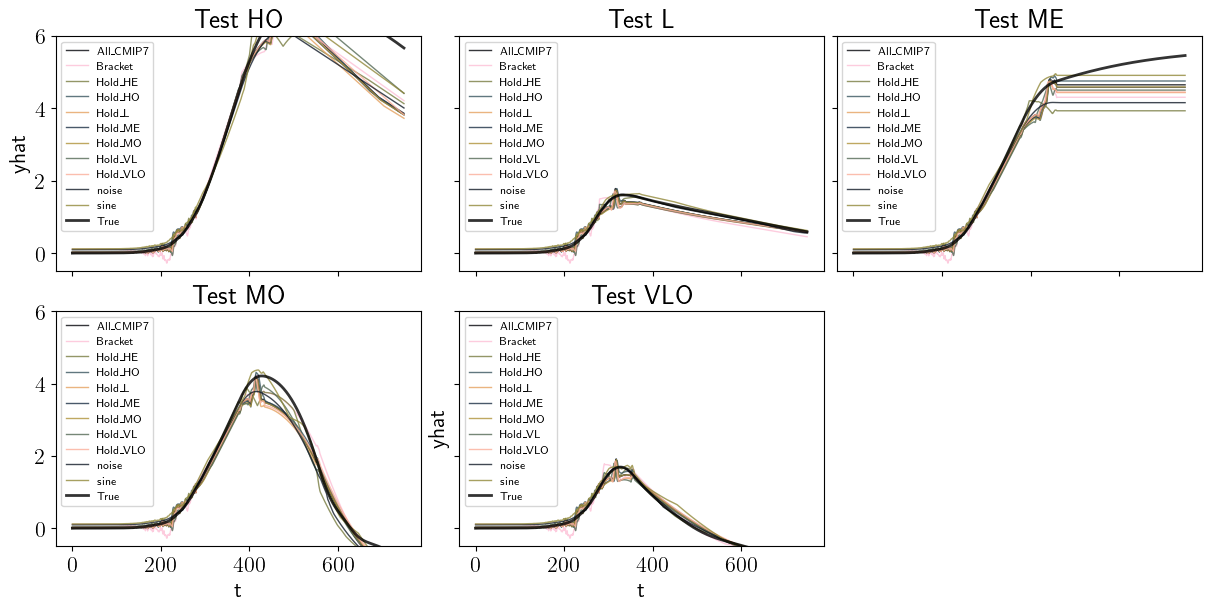

In [99]:
utils_MLP.plot_yhats_grid(error_dict_multi, yhat_dict_multi, delT_test_dict_priority_2)

['HO', 'VLO', 'L', 'ME', 'MO']


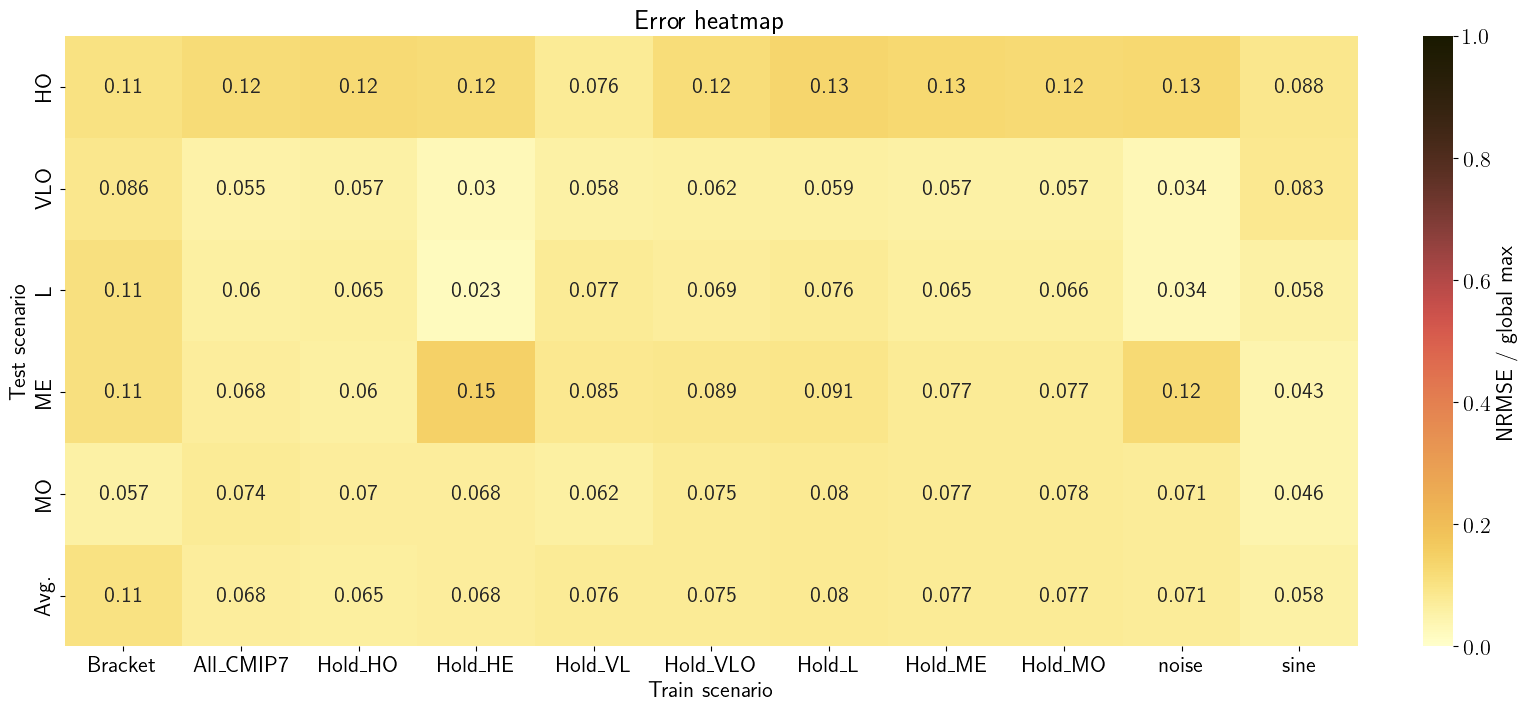

In [100]:
scenarios_train_multi = list(training_groups.keys())
utils_MLP.plot_error_heatmap(error_dict_multi, scenarios_train_multi, scenarios_test)